In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df=pd.read_csv('advertising.csv')

In [3]:
print(df.columns.tolist())

['TV', 'Radio', 'Newspaper', 'Sales']


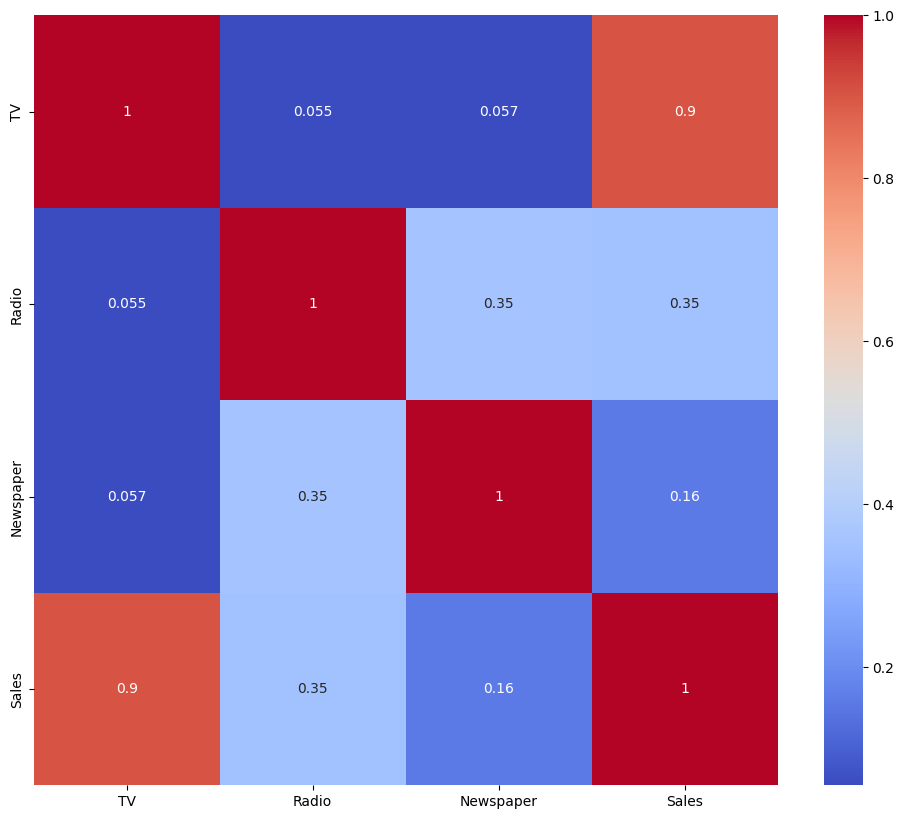

In [5]:
import seaborn as sns
corr = df.corr(numeric_only=True)
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [6]:
#split data training
y=df["Sales"]
y=np.array(y)
X=df.drop(columns="Sales")
X=np.array(X)

In [7]:
#split and standardization
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [8]:
#standardization
from sklearn.preprocessing import StandardScaler

In [9]:
scaler=StandardScaler()

In [10]:
X_train=scaler.fit_transform(X_train)
# x_train.()

In [11]:
X_test=scaler.transform(X_test)

In [12]:
len(X_test[0])

3

In [13]:
def online_learning(x, y, w):
    learning_rate=0.00000001
    for i in range(len(x)):
        y_pred = sum([w[j] * x[i][j] for j in range(len(x[i]))])
        y_pred+= w[-1] # bias term
        error = y[i] - y_pred
        for j in range(len(w)):
            if(j==len(w)-1):
                w[j] -= -2*learning_rate * error #bias term diffrention different
            else:
               w[j] -= -2*learning_rate * error * x[i][j]

w=[1,1,1]
online_learning(X_train,Y_train,w)

In [14]:
diff=0
for i in range(len(X_test)):
    y_pred=sum([w[j] * X_test[i][j] for j in range(len(X_test[i]))])+w[-1]
#    print("actual : ",y[i])
    diff+=abs(Y_test[i]-y_pred)

print("avg diff ",diff/len(X_train))

avg diff  4.377727461931719


In [15]:
#batch learning
def batch_learning(x, y, w, epochs=1000):
    learning_rate = 0.00000001  # Batch learning needs a smaller learning rate
    n = len(x)
    for epoch in range(epochs):
        gradient = [0] * len(w)
        for i in range(n):
            y_pred = sum([w[j] * x[i][j] for j in range(len(x[i]))]) + w[-1]
            error = y[i] - y_pred
            for j in range(len(x[i])):
                gradient[j] -= -2 * error * x[i][j]
            gradient[-1] -= -2 * error  # bias gradient
        # Update weights after processing all samples
        for j in range(len(w)):
            w[j] -= learning_rate * gradient[j]

# Usage:
w_batch = [1, 1, 1]
batch_learning(X_train, Y_train, w_batch)

In [16]:
diff=0
for i in range(len(X_test)):
    y_pred=sum([w_batch[j] * X_test[i][j] for j in range(len(X_test[i]))])+w_batch[-1]
#    print("actual : ",y[i])
    diff+=abs(Y_test[i]-y_pred)

print("avg diff ",diff/len(X_train))

avg diff  4.390908404720486
